In [ ]:
# !git clone https://github.com/febse/ta2025.git repo

import numpy as np
import plotly.graph_objects as go

try:
    from animations import *
except ImportError:
    from repo.animations import *


# Linear Algebra Essentials

## Vectors: Arrows, Lists

## Sums and Differences of Vectors

In [ ]:
# Plot the sum of two vectors as a triangle, keeping the original vectors in place


# Example vectors
a = np.array([1, 2])
b = np.array([2, -1])

fig = show_sum(a, b)

fig.show()

## Scalar Multiplication

In [ ]:
def generate_scaling_matrices(scale_factors):
    """Generate scaling matrices for a sequence of scale factors.
    
    Args:
        scale_factors: array or list of scale factors (uniform scaling)
    
    Returns:
        List of matrix lists, where each element is [S(scale)] for that scale factor
    """
    matrices_sequence = []
    for s in scale_factors:
        # Uniform scaling matrix
        S = np.array([[s, 0],
                      [0, s]])
        matrices_sequence.append([S])
    return matrices_sequence


# Create a range of scale factors from -2.0 to 2.0 (including negative values)
scale_factors = np.linspace(-2.0, 2.0, 81)

# Use heart points as the input set
pts = heart_param_points(n=60)

# Generate scaling matrices
matrices_sequence = generate_scaling_matrices(scale_factors)

# Show the transformation animation
fig = show_transformation(
    matrices_sequence=matrices_sequence,
    points=pts,
    L=5,
    title='Scaling Transformation: Interactive Slider',
    color_func=heart_line_color,
    frame_duration_ms=100
)

# Update slider labels to show scale factors instead of rotation angles
slider_steps = []
for idx, s in enumerate(scale_factors):
    step = {
        'label': f'{s:.2f}',
        'method': 'animate',
        'args': [[f'frame_{idx}'], {
            'mode': 'immediate',
            'frame': {'duration': 0, 'redraw': True},
            'transition': {'duration': 0}
        }]
    }
    slider_steps.append(step)

# Update the slider configuration
fig.update_layout(
    sliders=[{
        'active': 0,
        'currentvalue': {'prefix': 'Scale Factor: ', 'suffix': '', 'visible': True},
        'pad': {'t': 40},
        'steps': slider_steps
    }]
)

fig.show()

## Vector Magnitude

## Vector Similarity

In [ ]:
fig = show_dot_product_cosine()
fig.show()

In [ ]:
# The same with numpy

import numpy as np

u = np.array([1, 2, 3])
v = np.array([1, -1, 0])

dot_product = np.dot(u, v)
print(f"Dot product of u and v using np.dot: {dot_product}")

Dot product of u and v using np.dot: -1


In [ ]:
# The lengths (magnitudes) are

print(f"Length of u: {np.linalg.norm(u).round(3)}")
print(f"Length of v: {np.linalg.norm(v).round(3)}")

Length of u: 3.742
Length of v: 1.414


In [ ]:
# So the cosine similarity is

cosine_similarity = dot_product / (np.linalg.norm(u) * np.linalg.norm(v))
print(f"Cosine similarity between u and v: {cosine_similarity.round(3)}")

Cosine similarity between u and v: -0.189


In [ ]:
# Is it the same as the correlation?

np.corrcoef(u, v)

array([[ 1. , -0.5],
       [-0.5,  1. ]])

## Linear Transformations

In [ ]:
def f(x, y):
    return 1 * x + 1.95583 * y

# Example usage
print(f(2 * 1, 2 * 7))

2 * f(1, 7)

29.381619999999998


29.381619999999998

In [ ]:
f(2 * 1, 2 * 2)  # Should be 2 * f(1, 2)

9.823319999999999

In [ ]:
print("f(1, 2) + f(3, 4)", f(1, 2) + f(3, 4)) # Should be f(1 + 3, 2 + 4)
print("f(1 + 3, 2 + 4)", f(1 + 3, 2 + 4)) 

f(1, 2) + f(3, 4) 15.734979999999998
f(1 + 3, 2 + 4) 15.73498


In [ ]:
def F(x: np.ndarray) -> np.ndarray:
    return np.array([
        1 * x[0] + 1.95583 * x[1], # The first dot product (total in BGN)
        (0.51 * x[0] + 1 * x[1]) / 2 # The second dot product (average in EUR)
    ])

print("F([1, 2])", F(np.array([1, 2])))
print("F([1, 2])", F(np.array([4, 1])))


F([1, 2]) [4.91166 1.255  ]
F([1, 2]) [5.95583 1.52   ]


## Geometric View of Linear Transformations

In [ ]:
# Define target transformation matrix M

# M = np.array([
#     [0, -1],
#     [1, 0]
# ])

M = np.array([
    [1, 0],
    [0, 1]
])

# Build an interpolation from Identity to M: T(t) = I + t (M - I)
I = np.eye(2)
steps = 25
matrices_sequence = []
for k in range(steps + 1):
    t = k / steps
    T_t = I + t * (M - I)
    matrices_sequence.append([T_t])  # each frame applies one matrix

# Use heart points as the input set
pts = heart_param_points(n=60)

# Show the transformation animation
fig = show_transformation(
    matrices_sequence=matrices_sequence,
    points=pts,
    L=5,
    title='Heart Points: Identity → Target Matrix',
    color_func=heart_line_color,
    frame_duration_ms=300
)
fig.show()

In [ ]:
print("F([1, 0])", F(np.array([1, 0])))
print("F([0, 1])", F(np.array([0, 1])))

F([1, 0]) [1.    0.255]
F([0, 1]) [1.95583 0.5    ]


In [ ]:
# Use numpy to 

x = np.array([1, 2])
M = np.array([[1.95583, 1.70], [0, 1]])

M.dot(x)
M @ x

array([5.35583, 2.     ])

## Change of Basis

In [ ]:
import numpy as np

try:
    from animations import *
except ImportError:
    from repo.animations import *

# Define two vectors
a = np.array([1, 1])
b = np.array([2, 2])

fig = show_span(a, b)

fig.show()

In [ ]:
B = np.array([[1, 1], [-2, 2]])

B_inv = np.linalg.inv(B)

In [ ]:
B_inv @ B

array([[1., 0.],
       [0., 1.]])

In [ ]:
# Translate the coordinates (2, 5) to the basis B

B_inv @ np.array([2, 5])

array([-0.25,  2.25])

In [ ]:
# Define the new basis vectors
u = np.array([1, 1])
v = np.array([-2, 2])

fig = show_basis_vectors(u, v)
fig.show()

## Eigenvectors and Eigenvalues

In [ ]:
# Define the transformation matrix A
A = np.array([[5/4, 3/4],
            [3/4, 5/4]])

# Vectors to show
v3 = np.array([3, -5])
v4 = np.array([3, 1])
v5 = np.array([-4, 4])
v6 = np.array([2, 2])

fig = show_eigen_directions(A, [v3, v4, v5, v6])

fig.show()

In [ ]:
A

eigenvalues, eivenvectors = np.linalg.eig(A)
print(eivenvectors)

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## Diagonalization

In [ ]:
# Diagonal matrix (scaling x by 2, y by 0.5)
D = np.array([[2.0, 0.0], [0.0, 0.5]])

# Interpolate from identity to D
n_frames = 30
matrices_sequence = []
for k in range(n_frames+1):
    t = k / n_frames
    M = (1-t)*np.eye(2) + t*D
    matrices_sequence.append([M])

# Points to transform (heart shape)
pts = heart_param_points(n=40)

# Show transformation animation
fig = show_transformation(
    matrices_sequence=matrices_sequence,
    points=pts,
    L=5,
    title='Transformation Animation: Interpolating to Diagonal Matrix',
    color_func=heart_line_color,
    frame_duration_ms=200
)
fig.show()

## Matrix Multiplication (again)

### Weighted Sums of Columns

### Sum of Outer Products

## The Spectral Theorem

In [ ]:
print("The matrix A is:\n", A)

eigenvalues, eigenvectors = np.linalg.eig(A)
eigenvectors_inv = np.linalg.inv(eigenvectors)

The matrix A is:
 [[1.25 0.75]
 [0.75 1.25]]


In [ ]:
# The eigenvectors are the columns of the eigenvectors matrix

A = np.array([[5/4, 3/4],
              [3/4, 5/4]])

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors (columns):\n", eigenvectors)
print("Inverse of Eigenvectors matrix:\n", eigenvectors_inv)

Eigenvalues:
 [2.  0.5]
Eigenvectors (columns):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Inverse of Eigenvectors matrix:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


In [ ]:
# Layer 1

eigenlayer_1 = np.linalg.outer(eigenvectors[:,0], eigenvectors_inv[0,:])
print("Eigenlayer 1:\n", eigenlayer_1)

Eigenlayer 1:
 [[0.5 0.5]
 [0.5 0.5]]


In [ ]:
# Layer 2

eigenlayer_2 = np.linalg.outer(eigenvectors[:,1], eigenvectors_inv[1,:])
print("Eigenlayer 2:\n", eigenlayer_2)

Eigenlayer 2:
 [[ 0.5 -0.5]
 [-0.5  0.5]]


In [ ]:
reconstructed_A = eigenvalues[0] * eigenlayer_1 + eigenvalues[1] * eigenlayer_2

print("Reconstructed A from eigenlayers:\n", reconstructed_A)
print("Original A:\n", A)

Reconstructed A from eigenlayers:
 [[1.25 0.75]
 [0.75 1.25]]
Original A:
 [[1.25 0.75]
 [0.75 1.25]]


## Singular Value Decomposition {#sec-svd}

In [ ]:
A = np.array([
    [1, 0],
    [1, 0],
    [-1, 1]
])

A.T

array([[ 1,  1, -1],
       [ 0,  0,  1]])

In [ ]:
A.T @ A


array([[ 3, -1],
       [-1,  1]])

In [ ]:
A @ A.T

array([[ 1,  1, -1],
       [ 1,  1, -1],
       [-1, -1,  2]])

In [ ]:
A

array([[ 1,  0],
       [ 1,  0],
       [-1,  1]])

In [ ]:
# Let's check it with our toy matrix

U, Sigma, VT = np.linalg.svd(A)

print("U:\n", U.round(3))
print("Sigma\n", Sigma.round(3))
print("V^T:\n", VT.round(3))

U:
 [[-0.5   -0.5    0.707]
 [-0.5   -0.5   -0.707]
 [ 0.707 -0.707 -0.   ]]
Sigma
 [1.848 0.765]
V^T:
 [[-0.924  0.383]
 [-0.383 -0.924]]


In [ ]:
# U should be orthogonal 

(U.T @ U).round(3)

array([[ 1., -0., -0.],
       [-0.,  1.,  0.],
       [-0.,  0.,  1.]])

In [ ]:
# V_T should also be orthogonal

(VT.T @ VT).round(3)

array([[ 1., -0.],
       [-0.,  1.]])

## SDV using scikit-learn

In [ ]:
from sklearn.decomposition import PCA, TruncatedSVD

svd = TruncatedSVD(n_components=2)
svd_result = svd.fit_transform(A)

In [ ]:
svd.singular_values_.round(3)

array([1.848, 0.765])

In [ ]:
svd.components_.T.round(3)

array([[ 0.924,  0.383],
       [-0.383,  0.924]])

In [ ]:
# VT should be orthogonal as well

(VT.T @ VT).round(3)

array([[ 1., -0.],
       [-0.,  1.]])

In [ ]:
# Let's reconstruct the matrix A layer by layer

svd_layer_0 = np.outer(U[:,0], VT[0,:])
svd_layer_1 = np.outer(U[:,1], VT[1,:])

In [ ]:
Sigma.round(3)

array([1.848, 0.765])

In [ ]:
A_reconstructed = Sigma[0] * svd_layer_0 + Sigma[1] * svd_layer_1
print(A)
print(A_reconstructed.round(3))

[[ 1  0]
 [ 1  0]
 [-1  1]]
[[ 1.  0.]
 [ 1. -0.]
 [-1.  1.]]


In [ ]:
# The original data, expressed in terms of the two right eigenvalues

(A @ V_T).round(3)

array([[ 0.924,  0.383],
       [ 0.924,  0.383],
       [-1.307,  0.541]])

In [ ]:
V_T

array([[ 0.92387953,  0.38268343],
       [-0.38268343,  0.92387953]])

## Matrix Approximation using SVD (Image Compression)

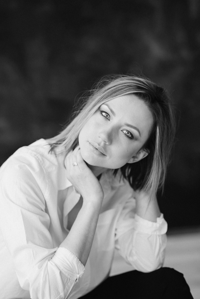

In [ ]:
from PIL import Image
import requests
from io import BytesIO
# Load the image as grayscale

url = "https://raw.githubusercontent.com/febse/data/refs/heads/main/ta/example_photo.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("L")
img = img.resize((200, int(img.height * 200 / img.width)))
display(img)


In [ ]:
# Convert the grayscale PIL image to a NumPy array and display as numbers

img_matrix = np.array(img)
print(img_matrix)
print("Shape:", img_matrix.shape, "Dtype:", img_matrix.dtype)

[[ 24  26  25 ...  36  34  30]
 [ 25  25  27 ...  35  32  30]
 [ 24  25  24 ...  34  31  30]
 ...
 [213 214 215 ... 157 156 155]
 [214 214 211 ... 155 155 153]
 [211 209 204 ... 152 152 152]]
Shape: (299, 200) Dtype: uint8


In [ ]:
# Do a SVD on the image matrix

U, S, VT = np.linalg.svd(img_matrix, full_matrices=False)


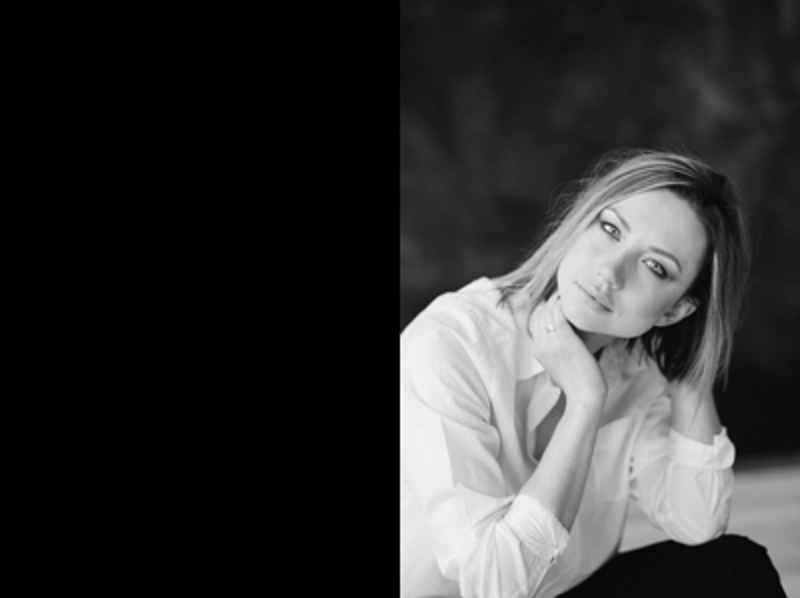

In [ ]:
# Compute the outer product of the first column of U with the first row of VT scaled by the first singular value

img_preview = show_reconstructed_image(199, U, S, VT)
display(img_preview)

## Application to Correlated Data

In [ ]:
np.random.seed(42)

n = 5

x = np.random.uniform(-2, 2, size=n)
y = x  + np.random.normal(0, 1, n)

hand_lengths = np.vstack([x, y]).T

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x, 
    y=y,
    mode='markers',
    marker=dict(size=8, color='blue')
))

fig.update_layout(
    title='Simulated left/right arm lengths',
    xaxis_title='Left arm (cm)',
    yaxis_title='Right arm (cm)',
    width=600,
    height=500
)

fig.show()

In [ ]:
U, Sigma, VT = np.linalg.svd(hand_lengths)


In [ ]:
U.round(3)

array([[-0.112, -0.368,  0.728,  0.452, -0.343],
       [ 0.792, -0.234,  0.128,  0.191,  0.514],
       [ 0.195,  0.73 ,  0.583, -0.298, -0.003],
       [ 0.029,  0.525, -0.254,  0.81 , -0.044],
       [-0.566,  0.024,  0.222,  0.117,  0.785]])

In [ ]:
Sigma

array([4.21147015, 0.75493145])

In [ ]:
VT.round(3)

array([[ 0.583,  0.812],
       [ 0.812, -0.583]])

In [ ]:
# Plot the hands data and the two VT components, scaled by the singular values
import numpy as np
import plotly.graph_objects as go

# Compute mean of x and y from the data
mean_x = np.mean(hand_lengths[:, 0])
mean_y = np.mean(hand_lengths[:, 1])
mean_point = np.array([mean_x, mean_y])

fig = go.Figure()

# Plot the hand_lengths matrix as a scatter plot (each row as a point)
fig.add_trace(go.Scatter(
    x=hand_lengths[:, 0],
    y=hand_lengths[:, 1],
    mode='markers',
    marker=dict(size=10, color='black'),
    name='Hand data'
))

# Plot the two VT components (right singular vectors), scaled by singular values, at the mean
colors = ['red', 'blue']
for i in range(min(2, VT.shape[0], Sigma.shape[0])):
    vec = VT[i, :2] * Sigma[i]
    tip = mean_point + vec
    fig.add_trace(go.Scatter(
        x=[mean_point[0], tip[0]],
        y=[mean_point[1], tip[1]],
        mode='lines+markers',
        line=dict(width=4, color=colors[i]),
        marker=dict(size=12, color=colors[i]),
        name=f'VT component {i+1} (scaled)'
    ))

fig.update_layout(
    title="Hand Data and VT Components (Scaled by Singular Values)",
    xaxis=dict(title='Dimension 1'),
    yaxis=dict(title='Dimension 2', scaleanchor='x', scaleratio=1),
    width=700, height=700
)

fig.show()